<div style="background: linear-gradient(135deg, #0a2342, #1a5276); padding: 30px; border-radius: 10px;">
  <h1 style="color: white; margin: 0; font-size: 2em;">⚓ Boat Stability Analysis</h1>
</div>

## Loadcase Definition

In [60]:
from pathlib import Path
import numpy as np
import pandas as pd

loadcase = pd.DataFrame([
    ["Lightship",              "1",   91.848, 10.446,  1.720, 0.000],
    ["Stores",                 "1",    0.400,  9.200,  1.100, 0.000],
    ["People at Main Deck",    "66",   4.950, 10.000,  5.369, 0.000],
    ["People at Sun Deck",     "20",   1.500,  7.200,  7.860, 0.000],
    ["Provisions and Effects", "16",   0.800, 10.200,  1.500, 0.000],
    ["Optional Equip.",        "1",    0.600, 10.100,  1.000, 0.000],
    ["Liferafts",              "1",    0.160,  2.300,  5.100, 0.000],
    ["Tender",                 "1",    1.000,  0.570,  1.850, 0.000],
    ["Fuel_stbd",              "10%",  0.627, 10.246, -0.984, 3.899],
    ["Fuel_port",              "10%",  0.627, 10.246, -0.984, 3.899],
    ["Fw_stbd",                "10%",  0.130, 14.175, -0.765, 0.360],
    ["Fw_port",                "10%",  0.130, 14.175, -0.765, 0.306],
    ["Black_stbd",             "10%",  0.065, 13.100, -0.839, 0.087],
    ["Black_port",             "10%",  0.065, 13.100, -0.839, 0.087],
], columns=["Item", "Quantity", "Weight_t", "Long_Arm_m", "Vert_Arm_m", "FSM_tm"])

loadcase["Long_Moment_tm"] = loadcase["Weight_t"] * loadcase["Long_Arm_m"]
loadcase["Vert_Moment_tm"] = loadcase["Weight_t"] * loadcase["Vert_Arm_m"]

# Define column headers
headers = ["Item", "Quantity", "Weight_t", "Long_Arm_m", "Vert_Arm_m", "FSM_tm", "Long_Moment_tm", "Vert_Moment_tm"]

# Headers list
headers = ["Item", "Qty", "Weight_t", "LCG_m", "VCG_m", "FSM_tm", "Long_Moment_tm", "Vert_Moment_tm"]

# Center-align headers with given widths
print(f"{headers[0]:^22} {headers[1]:^8} {headers[2]:^8} {headers[3]:^12} {headers[4]:^10} {headers[5]:^8} {headers[6]:^16} {headers[7]:^16}")
print("-" * 100)

# Print each row: text left-aligned, numbers right-aligned
for _, row in loadcase.iterrows():
    print(f"{row['Item']:<22} {row['Quantity']:<8} "
          f"{row['Weight_t']:8.2f} {row['Long_Arm_m']:12.2f} {row['Vert_Arm_m']:10.2f} "
          f"{row['FSM_tm']:8.2f} {row['Long_Moment_tm']:16.2f} {row['Vert_Moment_tm']:16.2f}")

         Item            Qty    Weight_t    LCG_m       VCG_m     FSM_tm   Long_Moment_tm   Vert_Moment_tm 
----------------------------------------------------------------------------------------------------
Lightship              1           91.85        10.45       1.72     0.00           959.44           157.98
Stores                 1            0.40         9.20       1.10     0.00             3.68             0.44
People at Main Deck    66           4.95        10.00       5.37     0.00            49.50            26.58
People at Sun Deck     20           1.50         7.20       7.86     0.00            10.80            11.79
Provisions and Effects 16           0.80        10.20       1.50     0.00             8.16             1.20
Optional Equip.        1            0.60        10.10       1.00     0.00             6.06             0.60
Liferafts              1            0.16         2.30       5.10     0.00             0.37             0.82
Tender                 1           

## Loadcase Summarry — Total Weight, LCG, VCG, FSM, Corrected VCG

In [53]:
total_weight      = loadcase["Weight_t"].sum()
total_long_moment = loadcase["Long_Moment_tm"].sum()
total_vert_moment = loadcase["Vert_Moment_tm"].sum()
total_fsm         = loadcase["FSM_tm"].sum()

lcg          = total_long_moment / total_weight
vcg          = total_vert_moment / total_weight
tcg          = 0.000   # symmetric loadcase, no transverse moments defined
fsc          = total_fsm / total_weight
vcg_corrected = vcg + fsc

print("Calculation Results")
print("-------------------------------")

print(f"Total Weight        : {total_weight:.3f} t")
print(f"LCG                 : {lcg:.3f} m")
print(f"VCG                 : {vcg:.3f} m")
print(f"TCG                 : {tcg:.3f} m")
print(f"FSM (total)         : {total_fsm:.3f} t·m")
print(f"FSC (= FSM / Δ)     : {fsc:.3f} m")
print(f"VCG corrected       : {vcg_corrected:.3f} m")

Calculation Results
-------------------------------
Total Weight        : 102.902 t
LCG                 : 10.270 m
VCG                 : 1.941 m
TCG                 : 0.000 m
FSM (total)         : 8.638 t·m
FSC (= FSM / Δ)     : 0.084 m
VCG corrected       : 2.025 m


---
<div style="background: linear-gradient(135deg, #0a2342, #1a5276); padding: 12px 20px; border-radius: 6px;">
  <span style="color: white; font-size: 1.2em; font-weight: bold;">🚢 Floating Status</span>
  <span style="color: #a8c8f0; margin-left: 12px;">Draft · LCB · MCT · Trim</span>
</div>

In [47]:
# ── Hydrostatic table entries (from hydrostatic curves/tables) ──────────────
# Enter the two bounding rows that bracket the current displacement

disp_low   = 102.5   # t    — displacement at lower bound
draft_low  = 1.533   # m
lcb_low    = 10.107  # m    — LCB from reference
mct_low    = 1.468   # t·m/cm

disp_high  = 105.0   # t
draft_high = 1.558   # m
lcb_high   = 10.097  # m
mct_high   = 1.473   # t·m/cm


# ── Interpolation function ──────────────────────────────────────────────────
def interp(low, high, d_low, d_high, d_target):
    return low + (high - low) * (d_target - d_low) / (d_high - d_low)


# ── Interpolated hydrostatic values ─────────────────────────────────────────
draft_interp = interp(draft_low, draft_high, disp_low, disp_high, total_weight)
lcb_interp   = interp(lcb_low,   lcb_high,   disp_low, disp_high, total_weight)
mct_interp   = interp(mct_low,   mct_high,   disp_low, disp_high, total_weight)


# ── Trim calculation ────────────────────────────────────────────────────────
# trim = Δ × (LCB − LCG) / MCT100
# positive trim = by stern

trim = total_weight * (lcb_interp - lcg) / mct_interp / 100


# ── Print results ───────────────────────────────────────────────────────────
print("Interpolated Hydrostatic Values")
print("--------------------------------")
print(f"Displacement used : {total_weight:.3f} t")
print(f"Draft             : {draft_interp:.4f} m")
print(f"LCB               : {lcb_interp:.4f} m")
print(f"MCT 1 cm          : {mct_interp:.4f} t·m/cm")
print(f"trim              : {trim:.4f} t·m/cm")


Interpolated Hydrostatic Values
--------------------------------
Displacement used : 102.902 t
Draft             : 1.5370 m
LCB               : 10.1054 m
MCT 1 cm          : 1.4688 t·m/cm
trim              : -0.1154 t·m/cm


---
<div style="background: linear-gradient(135deg, #0a2342, #1a5276); padding: 12px 20px; border-radius: 6px;">
  <span style="color: white; font-size: 1.2em; font-weight: bold;">📐 GZ Curve</span>
  <span style="color: #a8c8f0; margin-left: 12px;">KN Interpolation · GZ = KN − KG·sinθ</span>
</div>

In [57]:
# ── KN Table (from stability booklet) ────────────────────────────────────────
# Rows = angles, Columns = (displacement, trim) pairs
# Enter all bounding values that bracket current displacement & trim

angles = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

# Format: (disp, trim) : [KN values at each angle]
kn_table = {
    (102.50, -0.2): [0.000, 3.880, 4.892, 4.859, 4.697, 4.436, 4.112, 3.681, 3.140, 2.525],
    (105.00, -0.2): [0.000, 3.759, 4.901, 4.875, 4.717, 4.457, 4.131, 3.692, 3.142, 2.516],
    (102.50, -0.1): [0.000, 3.822, 4.869, 4.866, 4.705, 4.444, 4.118, 3.683, 3.137, 2.519],
    (105.00, -0.1): [0.000, 3.760, 4.901, 4.874, 4.716, 4.455, 4.127, 3.688, 3.139, 2.514],
}

# ── Interpolation ─────────────────────────────────────────────────────────────
# Current values from previous sections
disp_current = total_weight   # t
trim_current = trim           # m  (converted to m, table uses m)

# Extract unique disps and trims
disps = sorted(set(k[0] for k in kn_table))
trims = sorted(set(k[1] for k in kn_table))

d0, d1 = disps[0], disps[1]
t0, t1 = trims[0], trims[1]

def interp(v0, v1, x0, x1, x):
    return v0 + (v1 - v0) * (x - x0) / (x1 - x0)

# Step 1: interpolate over displacement at each trim
kn_at_t0 = [interp(kn_table[(d0,t0)][i], kn_table[(d1,t0)][i], d0, d1, disp_current) for i in range(len(angles))]
kn_at_t1 = [interp(kn_table[(d0,t1)][i], kn_table[(d1,t1)][i], d0, d1, disp_current) for i in range(len(angles))]

# Step 2: interpolate over trim
kn_final  = [interp(kn_at_t0[i], kn_at_t1[i], t0, t1, trim_current) for i in range(len(angles))]

# ── GZ = KN − KG·sinθ ────────────────────────────────────────────────────────
kg = vcg_corrected

# Define headers
headers = ["Angle (°)", "KN", "KG", "sin θ", "GZ"]

# Print centered header row
print(f"{headers[0]:^8}  {headers[1]:^8}  {headers[2]:^8}  {headers[3]:^8}  {headers[4]:^8}")
print("-" * 50)

# Print each row formatted
for _, row in gz_df.iterrows():
    print(f"{row['Angle (°)']:8.2f}  "
          f"{row['KN']:8.2f}  "
          f"{row['KG']:8.2f}  "
          f"{row['sin θ']:8.4f}  "
          f"{row['GZ']:8.4f}")

Angle (°)     KN        KG      sin θ       GZ   
--------------------------------------------------
    0.00      0.00      2.02    0.0000    0.0000
   10.00      3.82      2.02    0.1736    3.4680
   20.00      4.88      2.02    0.3420    4.1847
   30.00      4.87      2.02    0.5000    3.8540
   40.00      4.71      2.02    0.6428    3.4043
   50.00      4.44      2.02    0.7660    2.8939
   60.00      4.12      2.02    0.8660    2.3654
   70.00      3.68      2.02    0.9397    1.7810
   80.00      3.14      2.02    0.9848    1.1438
   90.00      2.52      2.02    1.0000    0.4943


---
<div style="background: linear-gradient(135deg, #0a2342, #1a5276); padding: 12px 20px; border-radius: 6px;">
  <span style="color: white; font-size: 1.2em; font-weight: bold;">📈 GZ Curve</span>
  <span style="color: #a8c8f0; margin-left: 12px;">Righting Lever vs Heel Angle</span>
</div>

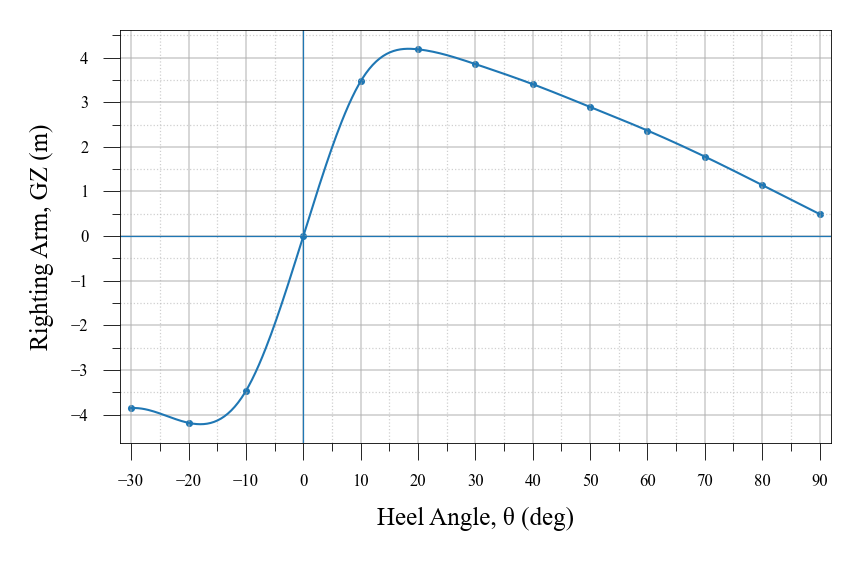

In [91]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# ── Extend to negative angles ────────────────────────────────────────────────
neg_angles = [-30, -20, -10]
neg_gz = [-gz_df[gz_df["Angle (°)"] == a]["GZ"].values[0] for a in [30, 20, 10]]

all_angles = neg_angles + gz_df["Angle (°)"].tolist()
all_gz = neg_gz + gz_df["GZ"].tolist()

all_angles = np.array(all_angles)
all_gz = np.array(all_gz)

idx = np.argsort(all_angles)
all_angles = all_angles[idx]
all_gz = all_gz[idx]

# ── Smooth spline ────────────────────────────────────────────────────────────
angle_smooth = np.linspace(all_angles.min(), all_angles.max(), 400)
spline = make_interp_spline(all_angles, all_gz, k=3)
gz_smooth = spline(angle_smooth)

# ── Typography scaled for small figure ───────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 6,
    "xtick.labelsize": 4,
    "ytick.labelsize": 4,
})

fig, ax = plt.subplots(figsize=(3,2), dpi=300)

# Curve
ax.plot(angle_smooth, gz_smooth, linewidth=0.5)

# Data points
ax.scatter(all_angles, all_gz, s=0.5)

# Labels
ax.set_xlabel("Heel Angle, θ (deg)")
ax.set_ylabel("Righting Arm, GZ (m)")

ax.set_xlim(-32, 92)

# Ticks
ax.set_xticks(np.arange(-30, 91, 10))
ax.set_xticks(np.arange(-30, 91, 5), minor=True)

ax.set_yticks(np.arange(-4, 5, 1))
ax.set_yticks(np.arange(-4, 5, 0.5), minor=True)

ax.tick_params(axis='both', which='major', width=0.2, length=4)
ax.tick_params(axis='both', which='minor', width=0.2, length=2)

# Grids
ax.grid(which='major', linestyle='-', linewidth=0.4, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.6)

# Reference axes
ax.axhline(0, linewidth=0.3)
ax.axvline(0, linewidth=0.3)

for spine in ax.spines.values():
    spine.set_linewidth(0.2)

plt.tight_layout()

plt.savefig("GZ_curve_publication.png", dpi=600, bbox_inches="tight")

plt.show()

In [94]:

# ── Polynomial fit to GZ curve ───────────────────────────────────────────────
angles = gz_df["Angle (°)"].values
gz_vals = gz_df["GZ"].values

coeffs = np.polyfit(angles, gz_vals, 5)   # 5th-order is typical for GZ curves
poly = np.poly1d(coeffs)
# ── Input ────────────────────────────────────────────────────────────────────
km = 2.20   # m, interpolated from hydrostatic table at current displacement and trim

# ── Basic stability parameter ────────────────────────────────────────────────
gm = km - vcg_corrected

# ── GZ from fitted polynomial ────────────────────────────────────────────────
def gz(angle_deg):
    return float(poly(angle_deg))

# ── Trapezoidal area under GZ curve ──────────────────────────────────────────
def gz_area(start_deg, end_deg, n=200):
    angles = np.linspace(start_deg, end_deg, n)
    gz_vals = poly(angles)
    return np.trapz(gz_vals, np.radians(angles))   # m·rad

# ── Maximum GZ and corresponding angle ───────────────────────────────────────
angles_search = np.linspace(0, 90, 1000)
gz_search = poly(angles_search)

theta_max = angles_search[np.argmax(gz_search)]
gz_max = gz(theta_max)

# ── Required areas ───────────────────────────────────────────────────────────
area_0_30 = gz_area(0, 30)
area_0_40 = gz_area(0, 40)
area_30_40 = gz_area(30, 40)

# ── IMO area requirement based on θmax ───────────────────────────────────────
if theta_max >= 30:
    area_required = 0.055
    area_note = "0.055 m·rad (θmax ≥ 30°)"
elif theta_max <= 15:
    area_required = 0.070
    area_note = "0.070 m·rad (θmax ≤ 15°)"
else:
    area_required = 0.055 + 0.001 * (30 - theta_max)
    area_note = f"{area_required:.4f} m·rad (15° < θmax < 30°)"

# ── Pass / Fail helper ───────────────────────────────────────────────────────
def check(condition):
    return "Pass" if condition else "Fail"

# ── Criteria table (formatted print) ─────────────────────────────────────────

headers = ["Criterion", "Actual_Value", "Required", "Status"]

# Print header
print(f"{headers[0]:<28} {headers[1]:>16} {headers[2]:>18} {headers[3]:>10}")
print("-" * 75)

# Print rows
rows = [
    ["Area 0°–30°", f"{area_0_30:.4f} m·rad", area_note, check(area_0_30 >= area_required)],
    ["Area 30°–40°", f"{area_30_40:.4f} m·rad", "≥ 0.030 m·rad", check(area_30_40 >= 0.030)],
    ["Maximum GZ", f"{gz_max:.4f} m", "≥ 0.200 m", check(gz_max >= 0.200)],
    ["Angle at Max GZ", f"{theta_max:.1f}°", "≥ 20°", check(theta_max >= 20)],
    ["Corrected GM", f"{gm:.4f} m", "≥ 0.150 m", check(gm >= 0.150)],
]

for r in rows:
    print(f"{r[0]:<28} {r[1]:>16} {r[2]:>18} {r[3]:>10}")

Criterion                        Actual_Value           Required     Status
---------------------------------------------------------------------------
Area 0°–30°                      1.7612 m·rad 0.0645 m·rad (15° < θmax < 30°)       Pass
Area 30°–40°                     0.6339 m·rad      ≥ 0.030 m·rad       Pass
Maximum GZ                           4.2061 m          ≥ 0.200 m       Pass
Angle at Max GZ                         20.5°              ≥ 20°       Pass
Corrected GM                         0.1753 m          ≥ 0.150 m       Pass


C:\Users\User\AppData\Local\Temp\ipykernel_9100\1799797519.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(gz_vals, np.radians(angles))   # m·rad
